**Seasonal Agriculture Performance Analysis**

**Major Data Analytics Project**

**Domain**:Agriculture

**Project Theme**: Seasonal Agriculture Performance

**Tools**:python,pandas,numpy,Matplotlib,Seaborn

**Project Goal**
Invigate how agricultural performance varies across seasons and identify meaningful patterns,trends,relationship and differences in the avilable data



**1.Problem Statement**
Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability and market conditions. As a result, agricultural performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agriculturalperformance changes across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigateseasonal differences in agricultural performance by identifying meaningful patterns, trends, relationships and variations within the available data.

**2. Project objective**

The primary objective of this project is to analyze agricultural data from different seasons and identify meaningful patterns, trends, relationships and differences in agricultural
performance.  
 Explore and understand the dataset.  
 Clean and prepare the data for analysis.  
 Examine how agricultural performance varies across seasons.  
 Identify important seasonal patterns and trends.  
 Investigate relationships between seasonal conditions and agricultural outcomes.  
 Compare relevant groups within different seasons.  
 Identify significant differences or unusual patterns.  
 Apply appropriate statistical and visualization techniques.  
 Interpret findings based on evidence from the dataset.  
 Develop meaningful conclusions and data-driven recommendations.

**3.Dataset**
The dataset farm-level agricultural records covering different seasons,locations,crops,environmental conditions,farming practices,production,costs,revenue,profit and resources usage.

**Dataset file:**/content/seasonal_agriculture_performance_dataset.csv


In [1]:
#importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
#lode the dataset
file_path = "/content/seasonal_agriculture_performance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded succesfully.")

Dataset loaded succesfully.


**4.Initial Data Understanding**

In [3]:
#Dataset shape

print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])

Number of rows: 4000
Number of columns: 28


In [ ]:
#top 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [4]:
#Bottom 5 rows
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [5]:
# Random Sample of records
df.sample(5,random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [6]:
#colume names
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [8]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,"4,000.00","3,952.00","4,000.00","4,000.00","4,000.00","4,000.00","3,960.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","3,968.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00","4,000.00"
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,186.04,5.07,0.83,5.27,43.25,"44,714.17","526,303.58","637,860.05","111,556.46","6,045.57",5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,60.26,1.98,0.10,13.36,126.88,"30,266.16","294,419.14","636,974.71","545,081.89","5,572.94",8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,40.00,0.50,0.65,0.30,0.15,"2,594.00","26,826.00","6,107.00","-1,019,223.00",128.00,0.14,5.00
25%,4.26,370.20,23.90,54.77,6.60,6.26,21.70,98.50,46.20,86.20,143.97,3.69,0.74,1.05,5.02,"21,429.25","274,577.50","207,517.25","-148,731.75","2,268.75",1.66,37.30
50%,7.89,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,186.25,5.12,0.83,1.74,11.77,"25,913.00","519,082.50","456,830.50","3,673.00","4,435.00",2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,227.20,6.40,0.91,2.84,24.36,"68,279.00","761,996.50","836,874.75","216,187.75","7,829.75",5.15,54.90
max,15.00,"1,395.20",39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,400.00,12.08,1.00,101.44,"1,424.40","131,240.00","1,349,990.00","5,080,900.00","4,345,421.00","40,902.00",79.80,88.90


In [9]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


**5.Data Quality Analysis**

In [10]:
#missing values
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [11]:
missing =df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_count": missing,
    "Missing_percentage": missing_percentage.round(2)
})

missing_summary[missing_summary["Missing_count"]>0]

,Missing_count,Missing_percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


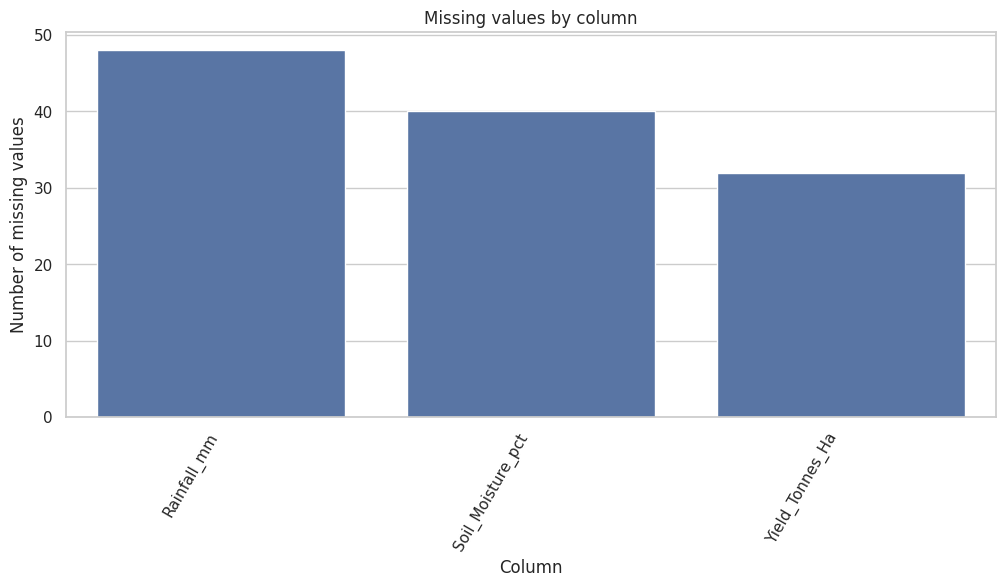

In [12]:
#visualize missing Values
plt.figure(figsize=(12,5))
missing_plot = missing[missing >0]
if len(missing_plot) > 0:
  sns.barplot(x=missing_plot.index, y=missing_plot.values)
  plt.xticks(rotation=60, ha='right')
  plt.ylabel("Number of missing values")
  plt.xlabel("Column")
  plt.title("Missing values by column")
  plt.show()
else:
  print("No missing values found.")


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
#remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("shape after removing duplicates:",df.shape)

shape after removing duplicates: (4000, 28)


In [15]:
#checking weather data types are updated or not
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


**Feature/Variable Review**

In [16]:
#check unique values for categorical columns
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
  print(f"\n{column}:")
  print(df[column].nunique(),"unique values")
  print(df[column].dropna().unique()[:20])



Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [17]:
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [18]:
# numerical and categorical columns
numerical_columns = df.select_dtypes(include="number").columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical columns:",numerical_columns)
print("Categorical columns:",categorical_columns)


Numerical columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']
Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


**7.Statistical Analysis**

In [19]:
#Descriptive statistics

stats = df[numerical_columns].describe().T
stats["range"]= stats["max"] - stats["min"]
stats["IQR"] = stats["75%"] - stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20","1,315.20",464.75
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00,39.00,9.60
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [20]:
# Median and standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "std_Dev":df[numerical_columns].std(),
    "Min":df[numerical_columns].min(),
    "Max":df[numerical_columns].max()
})

statistical_summary

,Mean,Median,std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,601.15,582.00,288.93,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.71,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [21]:
# Season descriptive summary

season_summary = df.groupby("Season")[numerical_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      852.08 854.75 182.55   
Rabi                 7.75   7.68 4.18      436.00 430.30 175.66   
Zaid                 8.09   8.09 4.16      299.42 283.30 153.98   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.20   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.05   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.17   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.20 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.96         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.90         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.64   1.95 14.42             46.31  13.24 135.70   
Rabi              5.08   1.66 12.83             41.49  11.08 121.90   
Zaid              4.67   1.45 11.32             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

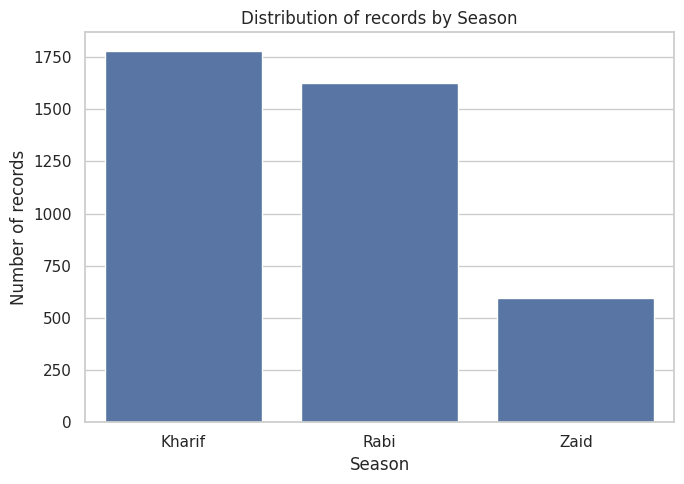

In [22]:
#Univariate: Season distribution

plt.figure(figsize=(7,5))
sns.countplot(data=df,x="Season")
plt.title("Distribution of records by Season")
plt.xlabel("Season")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

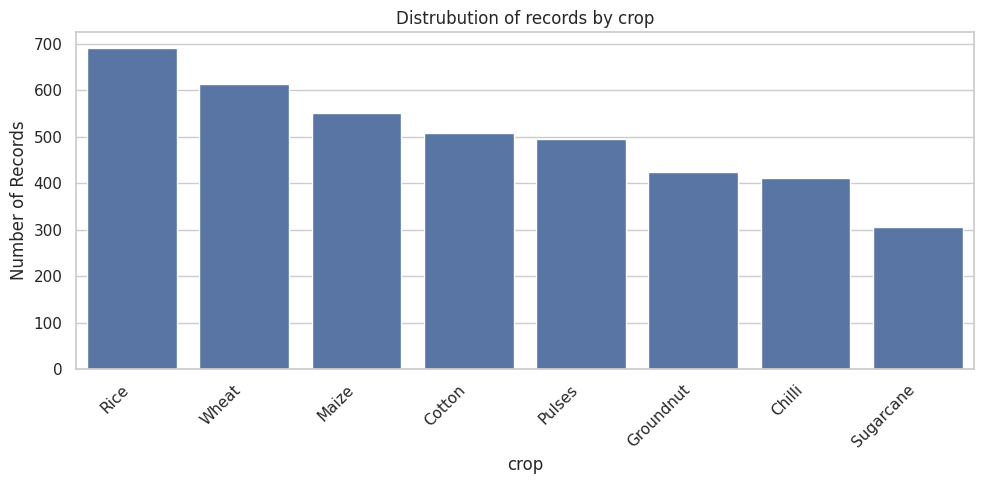

In [23]:
#univariate: Crop distribution

plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop", order=df["Crop"].value_counts().index)
plt.xticks(rotation=45,ha="right")
plt.title("Distrubution of records by crop")
plt.xlabel("crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

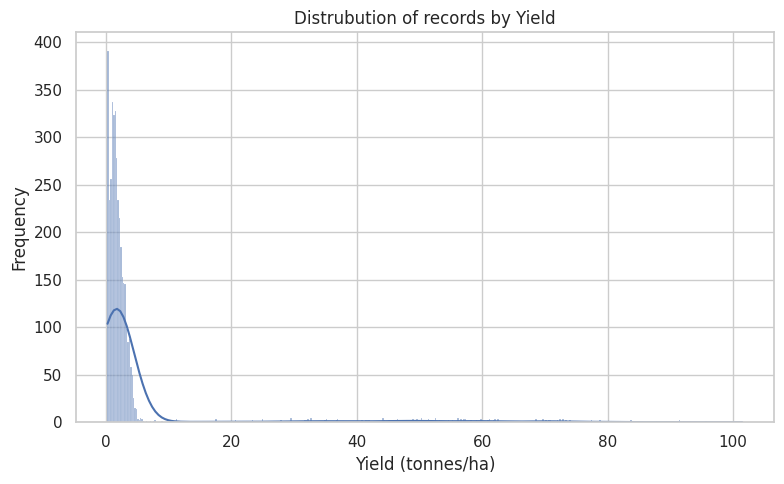

In [24]:
#univariate: Yield distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Yield_Tonnes_Ha",kde=True)
plt.title("Distrubution of records by Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

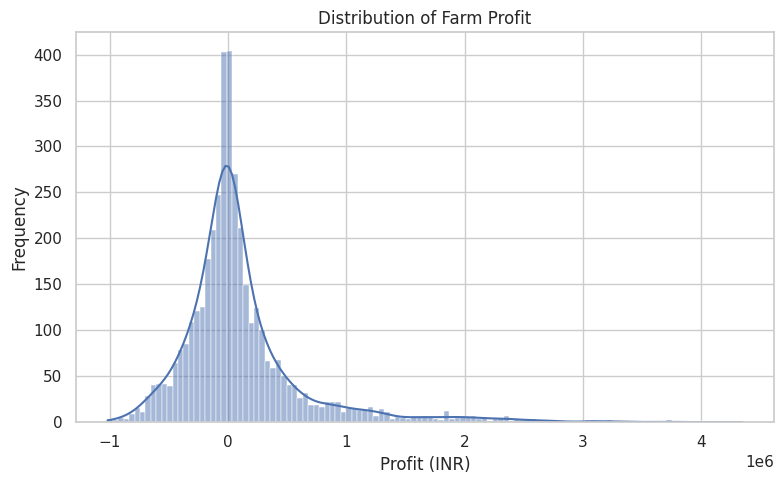

In [25]:
#univariate: Profit distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR",kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

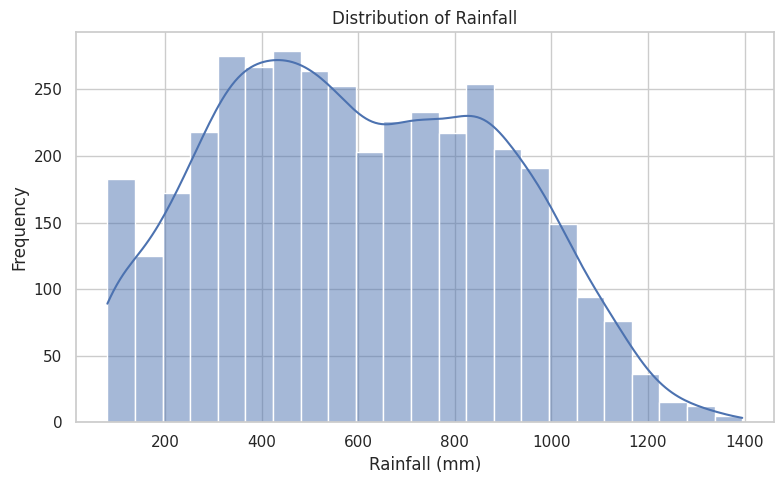

In [26]:
#Univariate: Rainfall distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

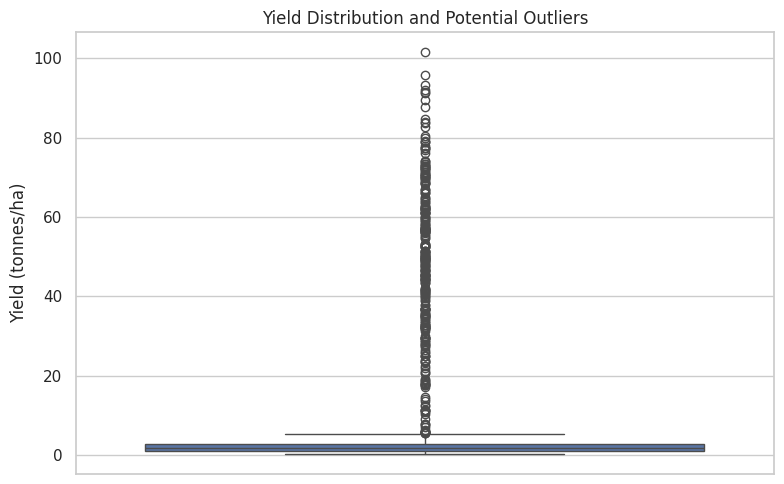

In [27]:
#univariate: Boxplot for yield


plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**9.Outlier Analysis**

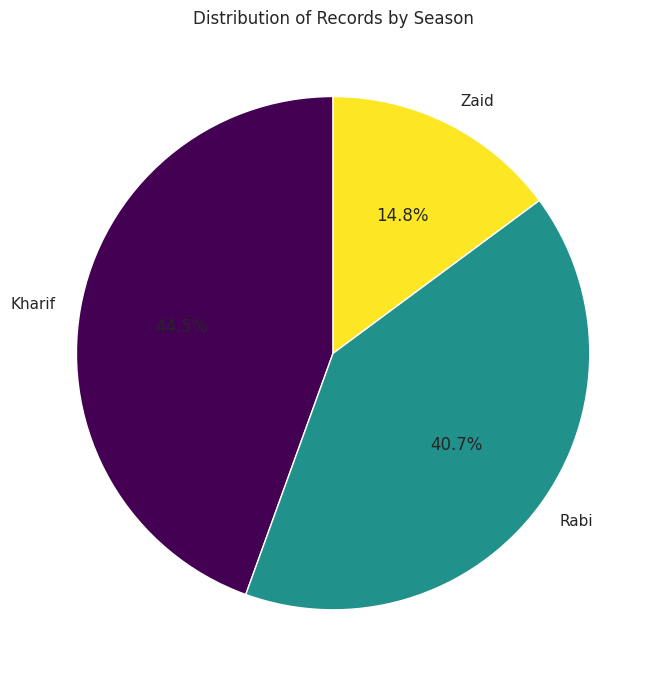

In [28]:
plt.figure(figsize=(7,7))
df["Season"].value_counts().plot.pie(autopct='%1.1f%%',startangle=90,cmap="viridis")
plt.title("Distribution of Records by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [29]:
#IQR-based outlier summary for numerical columns

outlier_summary = []

for col in numerical_columns:
  q1= df[col].quantile(0.25)
  q3= df[col].quantile(0.75)
  iqr = q3 - q1
  lower = q1 - 1.5 * iqr
  upper = q3 + 1.5 * iqr
  count = ((df[col] < lower) | (df[col] > upper)).sum()

  outlier_summary.append({
      "column":col,
      "lower_bound":lower,
      "upper_bound":upper,
      "outlier_count":count,
      "outlier_percentage":round(count/len(df)*100,2)
  })

outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    "outlier_count",ascending=False
     )
outlier_summary

,column,lower_bound,upper_bound,outlier_count,outlier_percentage
18,Profit_INR,"-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,-1.63,5.52,302,7.55
19,Water_Used_m3,"-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,19.14,352.04,15,0.38


**10.Bivariate Analysis**


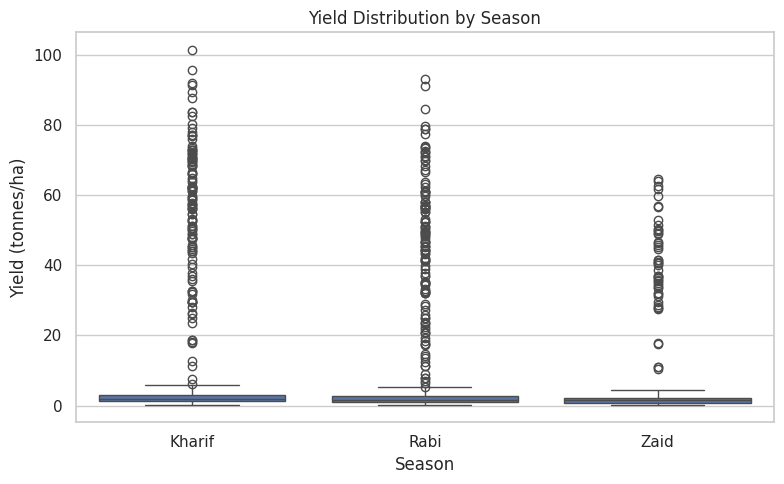

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("Yield Distribution by Season")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

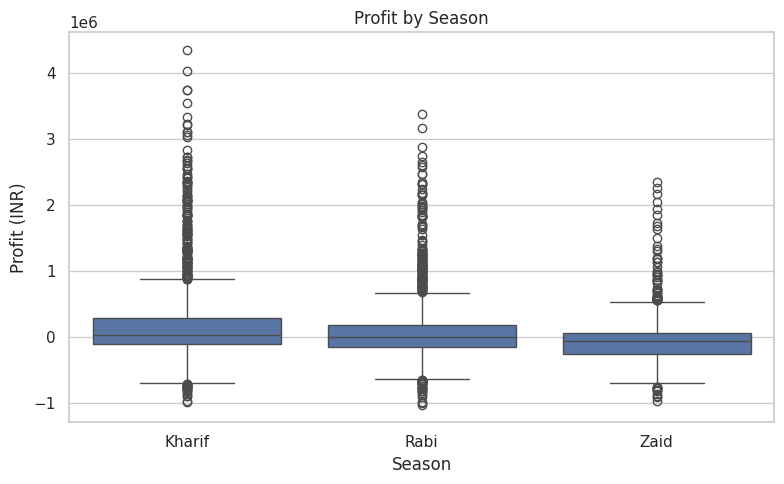

In [32]:
#Bivatiate: Season vs Profit

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

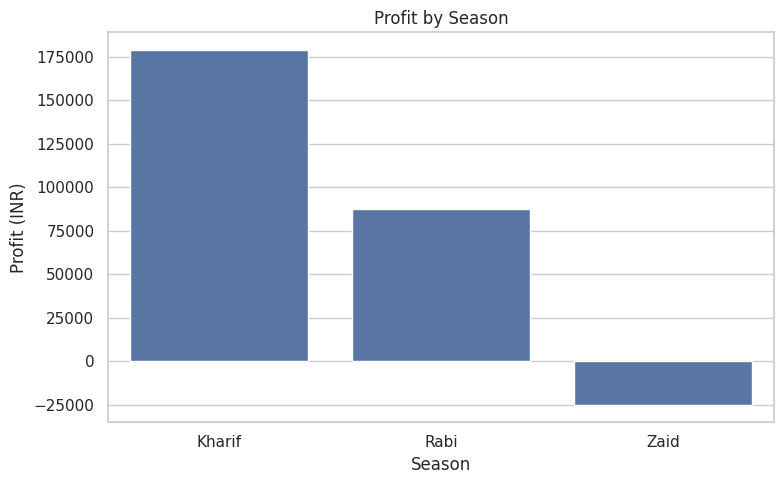

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("Profit by Season")
plt.xlabel("Season")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

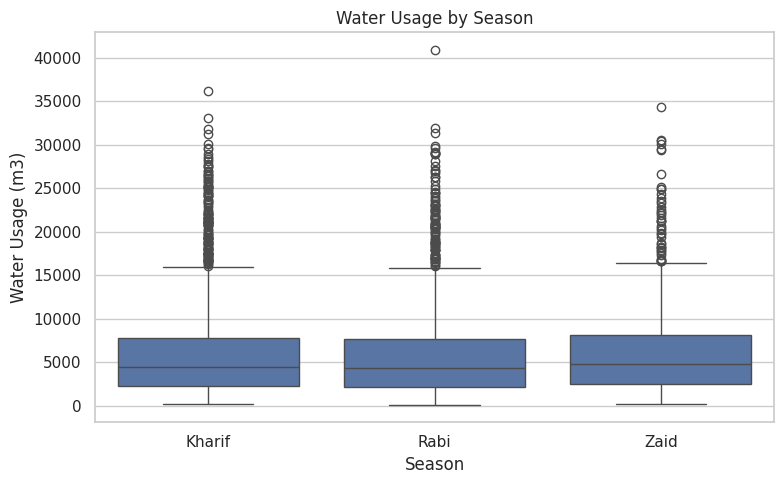

In [37]:
# Bivariate: Season vs Water Usage
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Usage (m3)")
plt.tight_layout()
plt.show()

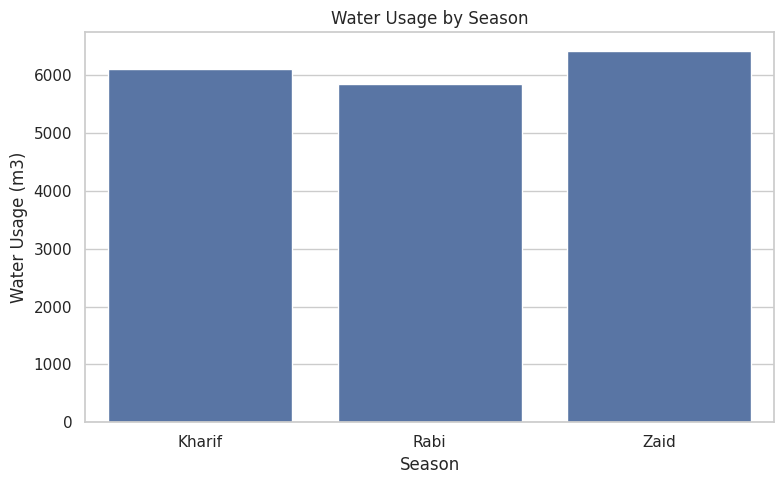

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Usage (m3)")
plt.tight_layout()
plt.show()

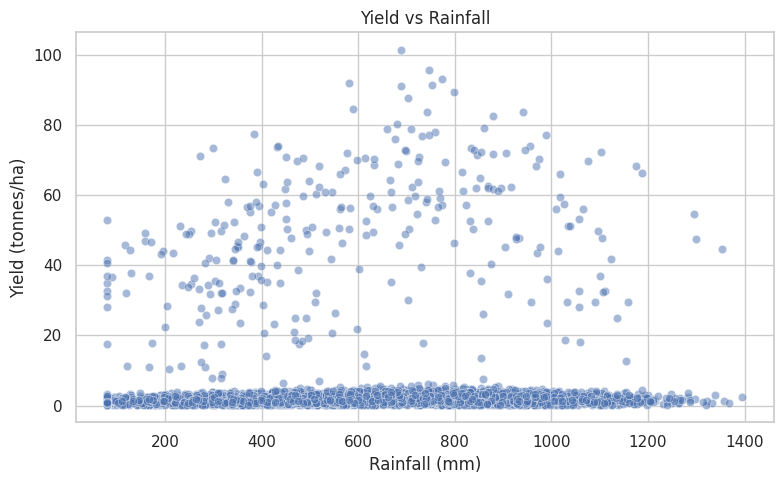

In [40]:
#Bivariate: Rainfall vs Yield

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha", alpha=0.5)
plt.title("Yield vs Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


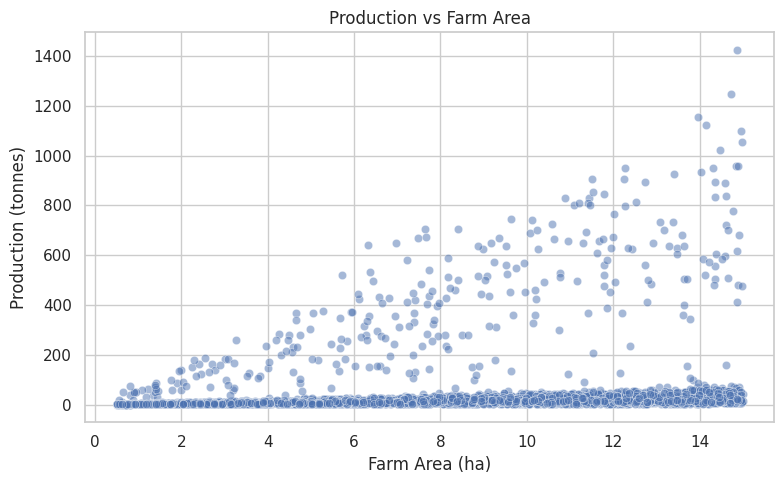

In [43]:
#Bivariate: Farm area vs Production
plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("Production vs Farm Area")
plt.xlabel("Farm Area (ha)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

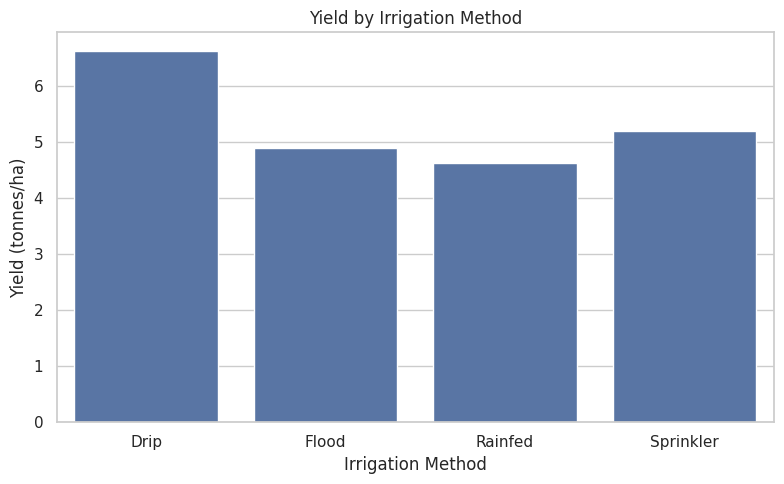

In [44]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

**11.Multivariate Analysis**

/tmp/ipykernel_537/1118063726.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Season")


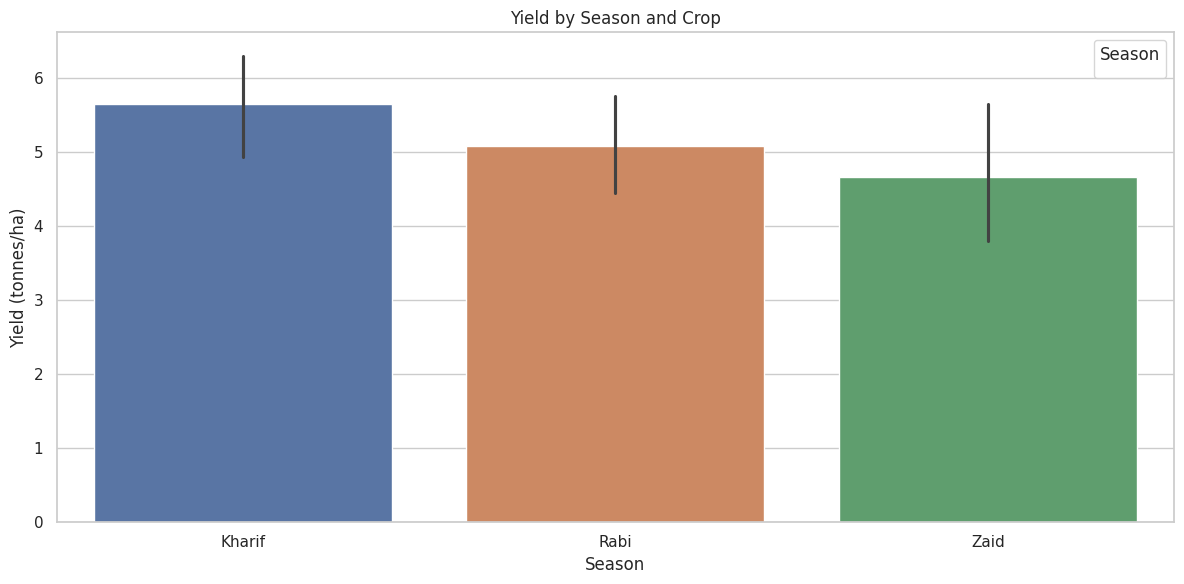

In [45]:
#Multivariate: Season Crop and Yield

plt.figure(figsize=(12,6))
sns.barplot(data=df,x="Season",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by Season and Crop")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

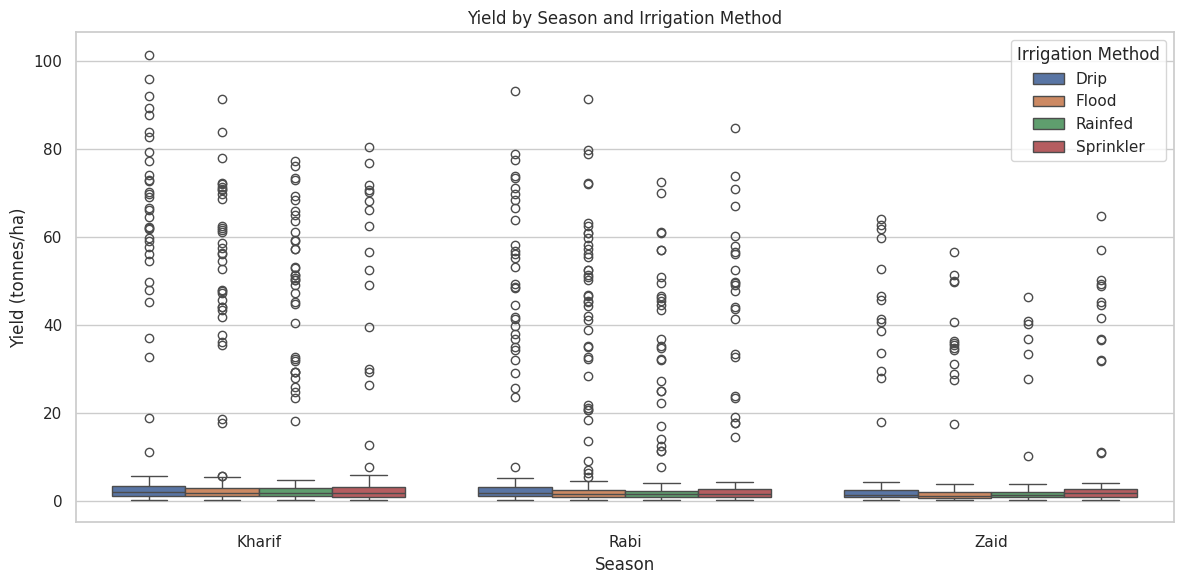

In [46]:
#Multivatiate: Season,irrigation and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha",hue="Irrigation_Method")
plt.title("Yield by Season and Irrigation Method")
plt.xlabel("Season")
plt.ylabel("Yield (tonnes/ha)")
plt.legend(title="Irrigation Method")
plt.tight_layout()
plt.show()

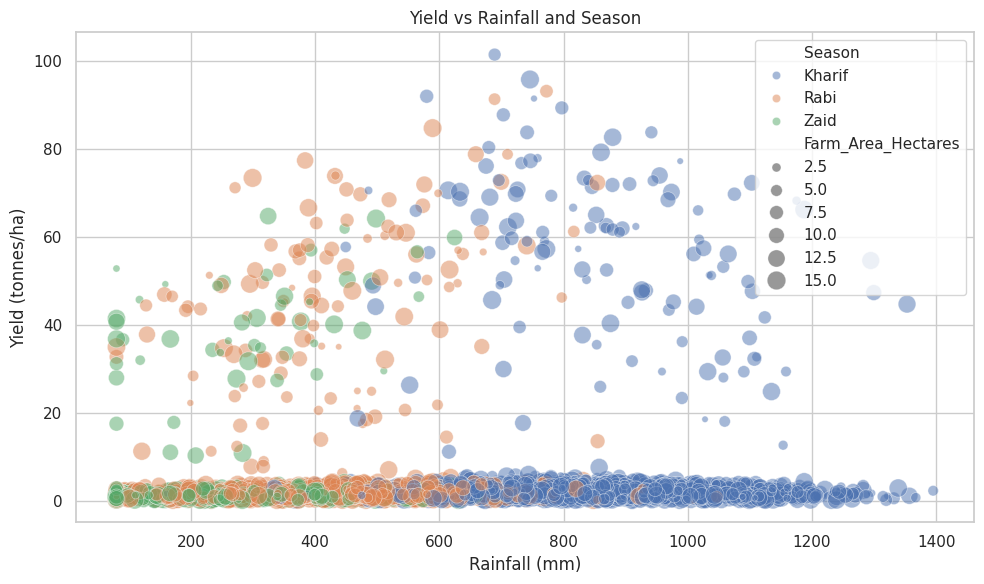

In [47]:
#Multivariate: Rainfall,yield and season

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",hue="Season",size="Farm_Area_Hectares",sizes=(20,180),alpha=0.5)
plt.title("Yield vs Rainfall and Season")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

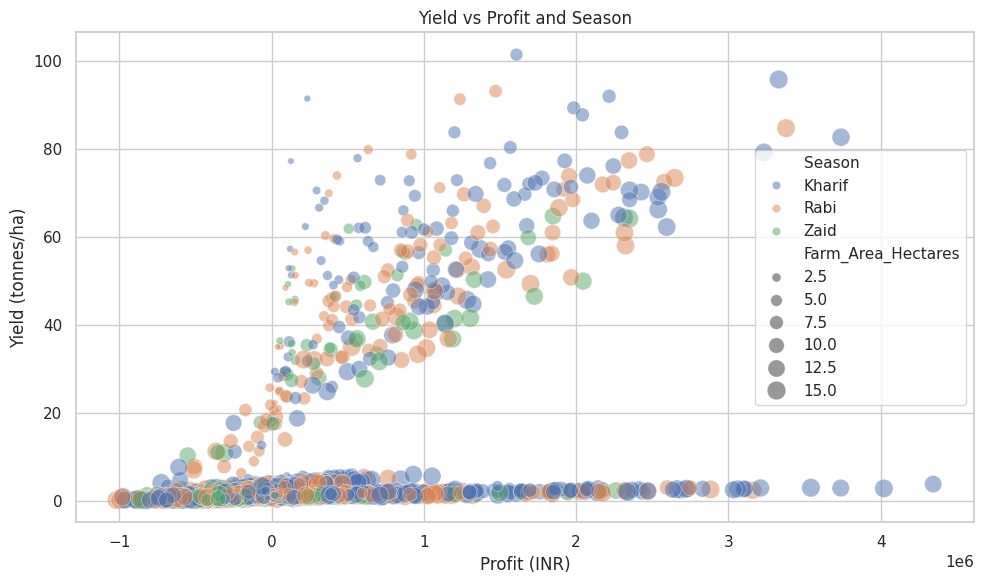

In [49]:
#Multivariate: Profit,yield and Season

plt.figure(figsize=(10,6))
sns.scatterplot(data=df,x="Profit_INR",y="Yield_Tonnes_Ha",hue="Season",size="Farm_Area_Hectares",sizes=(20,180),alpha=0.5)
plt.title("Yield vs Profit and Season")
plt.xlabel("Profit (INR)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()

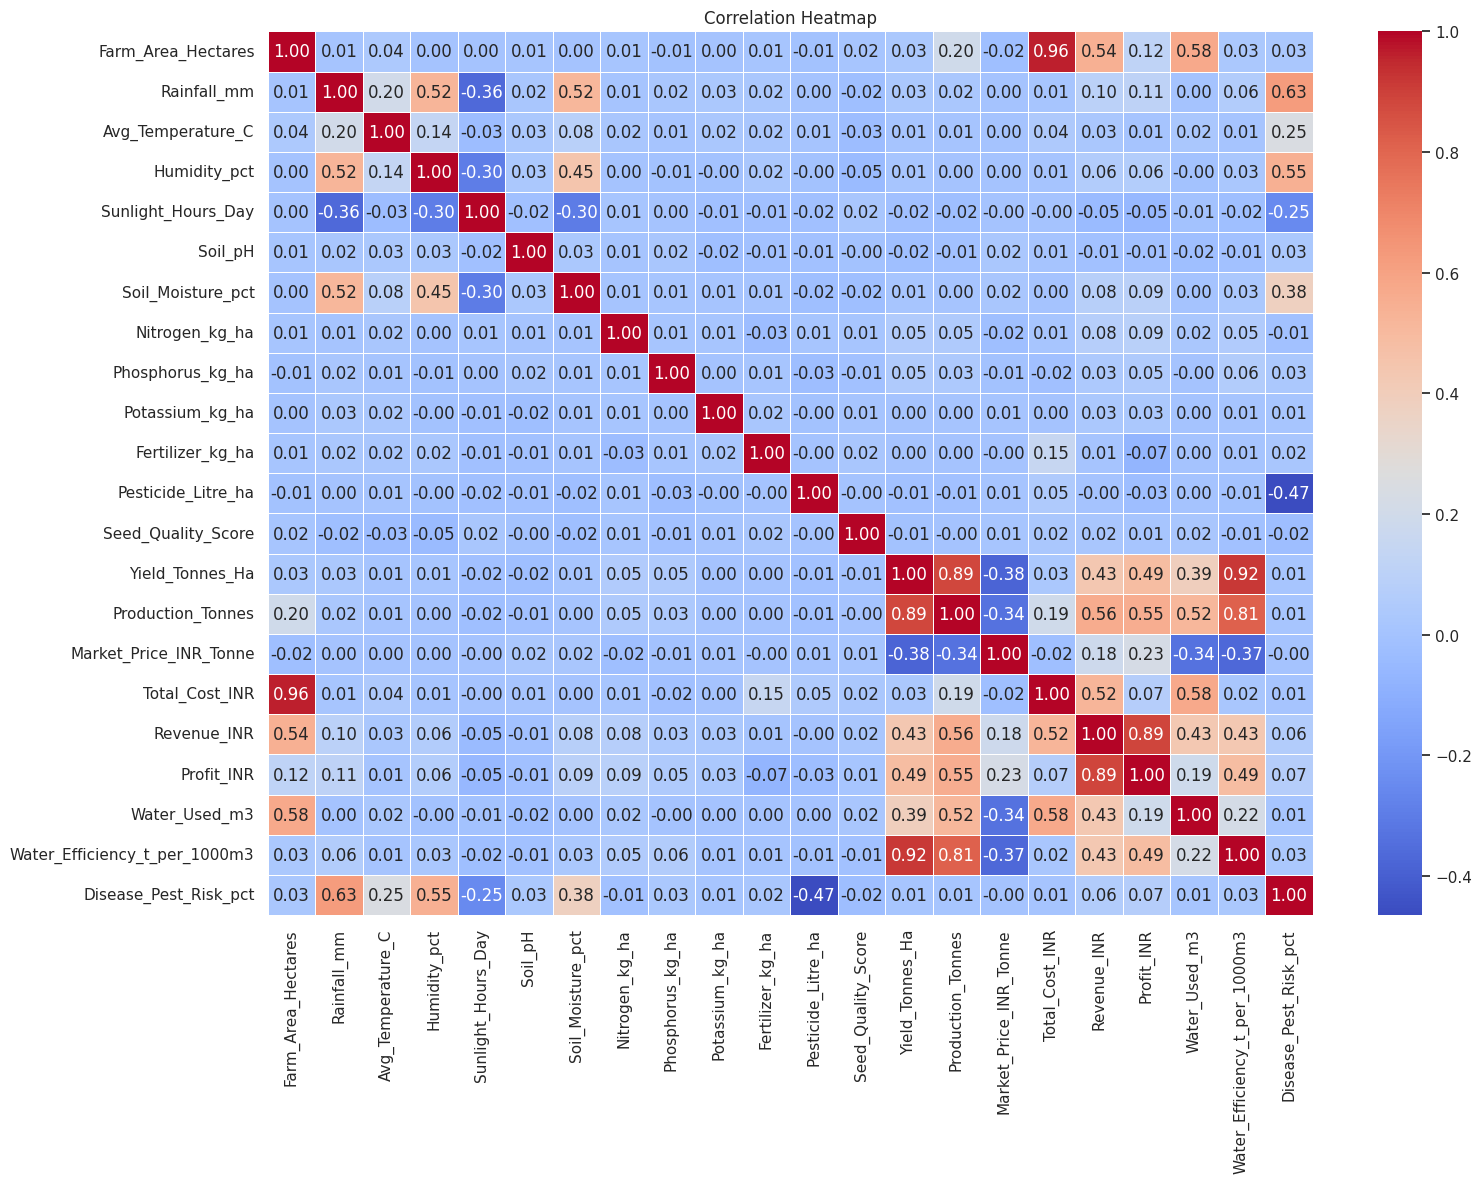

In [54]:
plt.figure(figsize=(16,12))
corr = df[numerical_columns].corr(numeric_only=True)
sns.heatmap(corr,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

**12.Seasonal comparsion**

In [58]:
#Geneeral season summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID","count"),
    Average_Yeild=("Yield_Tonnes_Ha","mean"),
    Average_Profit=("Profit_INR","mean"),
    Total_Profit=("Profit_INR","sum"),
    Total_Production=("Production_Tonnes","sum"),
    Average_Rainfall=("Rainfall_mm","mean"),
    Average_Water_Usage=("Water_Used_m3","mean")
).round(2)

season_metrics

,Records,Average_Yeild,Average_Profit,Total_Profit,Total_Production,Average_Rainfall,Average_Water_Usage
Season,,,,,,,
Kharif,1779,5.64,"178,914.65",318289158,"82,387.61",852.08,"6,102.20"
Rabi,1627,5.08,"87,689.47",142670768,"67,498.88",436.00,"5,846.99"
Zaid,594,4.67,"-24,804.82",-14734066,"23,098.35",299.42,"6,419.89"


**13.Additional Student-Driven /analysis**


**Student Analysis 1:Regional Economic Resilience Across Seasons**
**Question**:How does seasonal ecoonomic resilience vary across indian states,and which states exprience the highest financial vulnerability during the dry Zaid Season?

In [60]:
#Regional Profitability Across Seasons
state_Seasonal_profit = df.pivot_table(
    index="State",
    columns="Season",
    values="Profit_INR",
    aggfunc="median"
).round(2)

print(" Median Profit (INR)Across States and Seasons ")
display(state_Seasonal_profit)

 Median Profit (INR)Across States and Seasons 


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,"36,666.00","-6,366.00","-55,525.00"
Gujarat,"42,337.00","-7,532.50","-119,121.00"
Karnataka,"47,792.00",-301.00,"-53,754.00"
Madhya Pradesh,"29,770.00","-17,858.50","-92,531.00"
Maharashtra,"22,112.50","2,398.50","-63,377.00"
Punjab,"35,671.00","9,452.50","-22,060.00"
Tamil Nadu,"32,753.50","-11,212.50","-51,176.00"
Telangana,"58,909.50","11,408.00","-62,725.00"


<Figure size 1200x600 with 0 Axes>

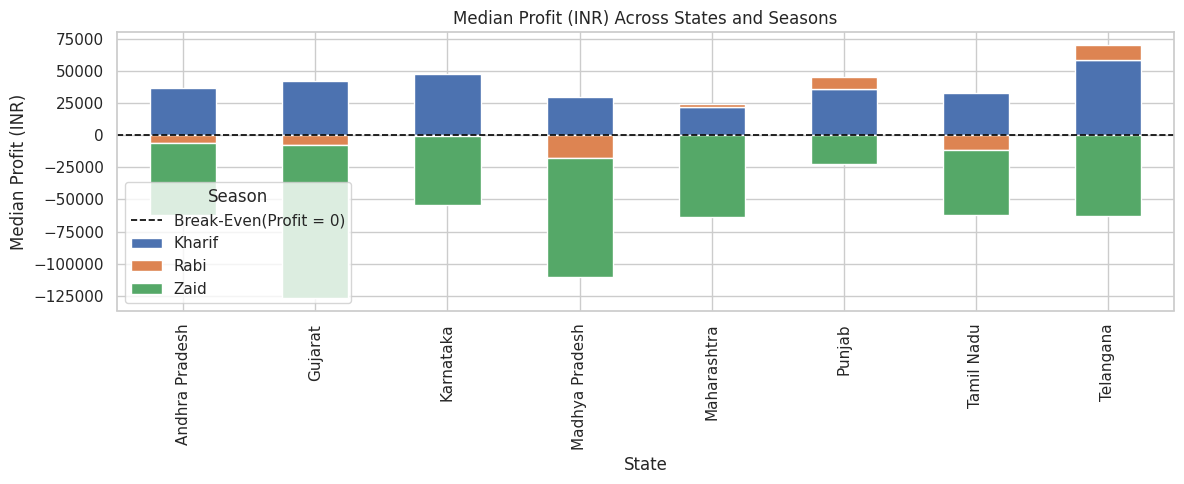

In [62]:
#visulization
plt.figure(figsize=(12,6))
state_Seasonal_profit.plot(kind="bar",figsize=(12,5),stacked=True)
plt.axhline(0,color="black",linestyle="--",linewidth=1.2,label="Break-Even(Profit = 0)")
plt.title("Median Profit (INR) Across States and Seasons")
plt.xlabel("State")
plt.ylabel("Median Profit (INR)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

**Student Analysis 2:** Farm Scale vs. Seasonal Profit Margin Risk


**​ Question**: Does larger farm scale (landholding size) protect farmers from seasonal losses, or does it amplify financial losses during unfavorable seasons like Zaid?

In [66]:
#Student Analysis 2: Farm Size Categorization and Seasonal Performance
df["Farm_Scale"] = pd.qcut(
    df["Farm_Area_Hectares"],
    q=3,
    labels=["Smallholder (<5.2 ha)", "Medium (5.2-10.3 ha)", "Large (>10.3 ha)"]
)

# Create the 'Profitability_Flag' column
df["Profitability_Flag"] = df["Profit_INR"].apply(lambda x: "Profitable" if x > 0 else "Not Profitable")

scale_seasonal_kpi = df.groupby(["Farm_Scale", "Season"], observed=False).agg(
    Median_Profit=("Profit_INR", "median"),
    Mean_Profit=("Profit_INR", "mean"),
    Avg_Yield=("Yield_Tonnes_Ha", "mean"),
    Profitable_Ratio=("Profitability_Flag", lambda s: (s == "Profitable").mean() * 100)
).round(2)

print("Performance Breakdown by Farm Scale and Season ")
display(scale_seasonal_kpi)

Performance Breakdown by Farm Scale and Season 


Median_Profit  Mean_Profit  Avg_Yield  \
Farm_Scale            Season                                          
Smallholder (<5.2 ha) Kharif      14,825.00    55,109.63       4.72   
                      Rabi        -5,811.00    18,938.91       4.15   
                      Zaid       -15,824.50     5,638.52       4.74   
Medium (5.2-10.3 ha)  Kharif      96,070.00   206,227.65       6.45   
                      Rabi        -3,888.50   103,019.91       5.98   
                      Zaid       -98,527.00   -41,421.01       3.93   
Large (>10.3 ha)      Kharif      75,045.00   273,532.85       5.79   
                      Rabi         2,460.00   145,440.40       5.13   
                      Zaid      -224,203.00   -34,389.36       5.39   

                              Profitable_Ratio  
Farm_Scale            Season                    
Smallholder (<5.2 ha) Kharif             56.64  
                      Rabi               46.51  
                      Zaid               41.11  
Medium (5.2-10.3 ha)  Kharif             61.23  
                      Rabi               49.45  
                      Zaid               34.42  
Large (>10.3 ha)      Kharif             55.70  
                      Rabi               50.77  
                      Zaid               31.66

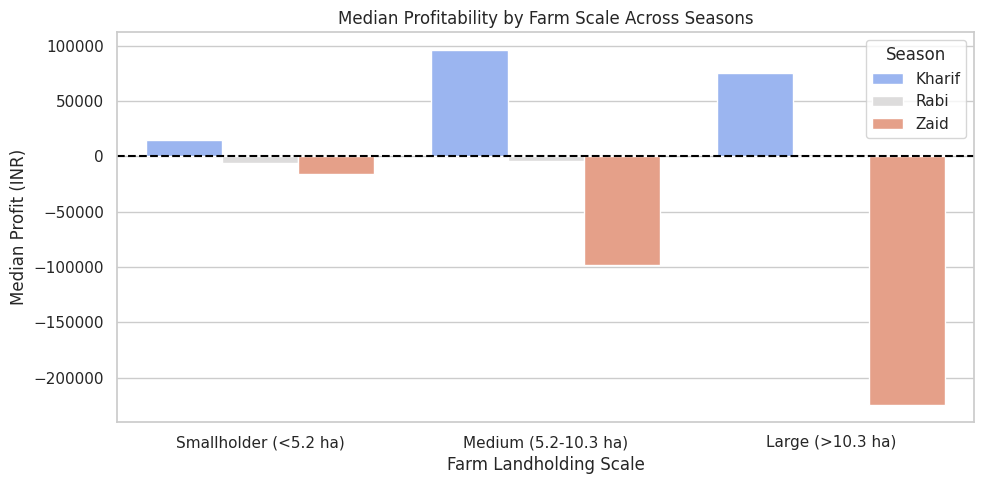

In [67]:
#Visualization
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x="Farm_Scale",
    y="Profit_INR",
    hue="Season",
    estimator=np.median,
    errorbar=None,
    palette="coolwarm"
)
plt.axhline(0, color="black", linestyle="--")
plt.title("Median Profitability by Farm Scale Across Seasons")
plt.ylabel("Median Profit (INR)")
plt.xlabel("Farm Landholding Scale")
plt.tight_layout()
plt.show()

**Student Analysis 3:** Environmental Triggers & Pest Risk Dynamics


**​Analytical Question:** How strongly do seasonal humidity and rainfall drive pest/disease risk, and do farmers' current pesticide application levels successfully mitigate that risk?

In [69]:
# Student Analysis 3: Environmental Disease Triggers and Pesticide Efficiency
env_pest_summary = df.groupby("Season").agg(
    Avg_Humidity_pct=("Humidity_pct", "mean"),
    Avg_Rainfall_mm=("Rainfall_mm", "mean"),
    Avg_Pest_Risk_pct=("Disease_Pest_Risk_pct", "mean"),
    Avg_Pesticide_L_ha=("Pesticide_Litre_ha", "mean")
).round(2)

print(" Seasonal Environmental Triggers vs Pest Risk ")
display(env_pest_summary)


 Seasonal Environmental Triggers vs Pest Risk 


,Avg_Humidity_pct,Avg_Rainfall_mm,Avg_Pest_Risk_pct,Avg_Pesticide_L_ha
Season,,,,
Kharif,71.81,852.08,54.47,5.08
Rabi,57.89,436.00,40.48,5.02
Zaid,52.01,299.42,38.22,5.17


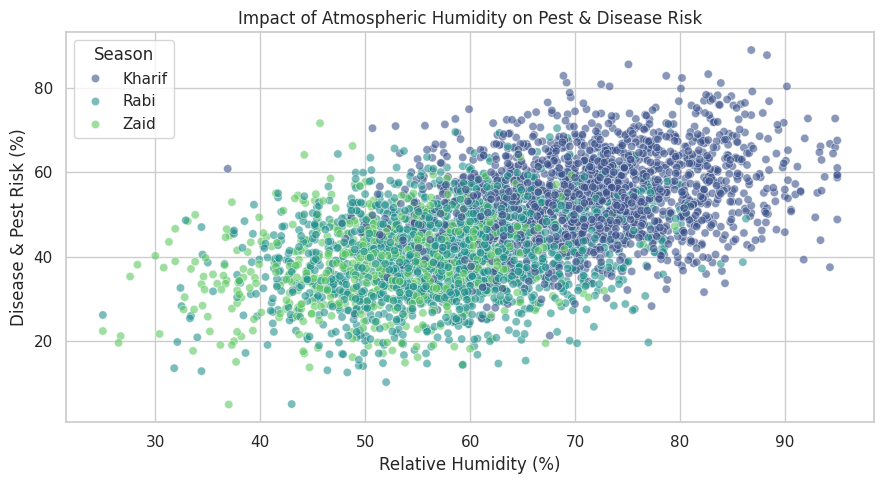

In [70]:
# Visualizing Correlation: Humidity vs Disease Risk by Season
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="Humidity_pct",
    y="Disease_Pest_Risk_pct",
    hue="Season",
    alpha=0.6,
    palette="viridis"
)
plt.title("Impact of Atmospheric Humidity on Pest & Disease Risk")
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Disease & Pest Risk (%)")
plt.tight_layout()
plt.show()

**14.Key insights**

**Insight 1**:Heavy Losses During Zaid Season:

**​Observation:** Farm profits drop heavily in summer (Zaid), with most farmers losing money.  
**​Evidence:** Kharif has a median profit of ₹38,808, Rabi drops to -₹3,187, and Zaid falls to -₹62,144 (only 35.5% profitable farms).  
**​Interpretation:** High summer heat and low rainfall make farming costs higher than what farmers earn at harvest.  
**​Limitation:** Cash crops still make money in Zaid, so not every individual farm loses money.  


**Insight 2**: Cash Crops Earn More Than Cereal Crops

**​Observation:** Cash crops stay profitable year-round, while food grains lose money.  
**​Evidence:** Sugarcane makes over ₹550,000 median profit in all seasons, while Rice, Wheat, and Maize show negative median profits across all seasons.

**​Interpretation**:Market selling prices for grains are too low to cover rising seed, water, and labor expenses.  
**Limitation**:The dataset does not include government MSP support or bonus subsidies that farmers might receive in real life.

**Insight 3**: Drip Irrigation Works Better Than Flood Irrigation
**​Observatio**n: Drip systems save water and give better profits than flood watering.  
**​Evidence**: Drip irrigation gives 6.27 t/1000m³ efficiency and ₹52,895 median profit, while flood uses the most water (8,026 m³) and loses money (-₹12,131 median).  
**​Interpretation**: Drip delivers water right to the roots, avoiding wasted water and costly electric pumping.  
**​Limitation**: We do not know the upfront setup cost or loan interest required to buy drip equipment.

**​Insight 4**: Pest Attacks Peak During the Monsoon

**​Observation**: Pest and crop disease risks are much higher during the rainy season.  
**​Evidence**: Pest risk averages 54.5% in Kharif alongside 71.8% humidity, compared to about 38.2% risk in dry Zaid.  
**​Interpretation**: Warm, damp weather during rainy months helps insects and fungi spread much faster.  
**​Limitation**: The data only tracks broad risk percentages, not specific pests or bug species attacking the fields.

**Insight 5**: Farmers Spray the Same Pesticide Regardless of Risk
**​Observation**: Chemical pesticide usage does not change between wet and dry seasons.  
**Evidence**: Farmers spray roughly 5.0 to 5.2 litres per hectare in all three seasons, even though Kharif has 16% higher pest risk than Zaid.  
**​Interpretation**: Farmers follow a fixed spraying schedule instead of checking whether pests are actually present.  
**​Limitation**: We only see total litres sprayed, not the chemical strength or exact spray dates

**​Insight 6**: Large Farms Lose More Money in Bad Seasons.

**​Observation**: Bigger farms suffer larger monetary losses during difficult seasons.  
**​Evidence**: In Zaid, small farms lose a median of -₹15,825, medium farms lose -₹98,527, and large farms lose -₹224,203.  
**​Interpretation**: Large farms spend more on labor, diesel, and inputs, so when harvests fail, their losses multiply.  
**​Limitation**: Total losses look bigger on large farms simply because they have more land area, not necessarily worse farming skills

**​Insight 7**: Summer Losses Happen in Every State.

**​Observation**: Zaid season losses happen across all monitored states, not just one dry area.  
**​Evidence**: All 8 states show negative median profits in Zaid, ranging from -₹22,060 in Punjab to -₹119,121 in Gujarat.  
**​Interpretation**: Extreme summer heat and water scarcity create challenges that affect all regions.  
**​Limitation**: State-wide numbers combine dry districts and well-watered river basins into one average score.

**​Insight 8**: Medians Are More Reliable Than Means for This Data.

**​Observation**: Average numbers are pulled upward by a few extreme values and give an inaccurate picture.  
**​Evidence**: Overall mean profit is ₹111,556, but median profit is only ₹3,673 (skewness is 2.42).  
**​Interpretation**: A small number of wealthy sugarcane farms lift the average, while the typical farmer operates near break-even.  
​Limitation **bold text**: Looking only at medians hides the total food production volume produced by the top commercial farms.

**15.Recommendiations**

**1.​Switch from Flood to Drip Watering:**

**​Finding**: Flood irrigation uses the most water (8,026 m³) and loses money (-₹12,131 median profit). Drip irrigation doubles water efficiency and makes a positive median profit of ₹52,895.  
**​Advice**: Encourage farmers to install drip lines to cut water bills and power costs.  
**​Limitation**: Drip kits cost money upfront that poor farmers cannot afford without government grants.


**2.​Stop Growing Food Grains in Summer (Zaid)**:

**​Finding**: Farmers lose heavy money growing summer grains like Rice (-₹183,632 median) and Maize (-₹147,456 median). Cash crops like Chilli and Sugarcane still make a profit.  
**​Advice**: Do not plant water-thirsty grains in summer; switch to heat-tolerant pulses or vegetables.  
**​Limitation**: Farmers often need to grow grain just to feed their families and livestock.


**3.​Spray Pesticides Based on Weather, Not Habits**:
**​Finding**: Farmers spray roughly 5 litres of chemical per hectare in all seasons, even though pest attacks fall by nearly 30% after monsoon season.  
**​Advice**: Spray only during damp months when bugs are active instead of following a fixed calendar.  
**​Limitation**: We do not know the exact bug types or chemical strengths used.
​Leave Empty Fields on Large Farms in Summer:
**​Finding**: Big farms lose over ₹220,000 median profit in summer because labor and diesel costs stay high while crops wither.  
**​Advice**: Large owners should rest poor-quality fields during peak summer to avoid wasting money.  
**​Limitation**: Leaving land empty leaves hired laborers without seasonal work.

**16.conclution**


1.​Summer Is Tough for Everyone: Farming does well during monsoon Kharif (58%
profitable farms) but crashes in summer Zaid (only 35% profitable farms, with a median loss of -₹62,144).  
​2.Grains Lose Money, Cash Crops Pay Bills: Essential food crops like Rice, Wheat, and Maize lose money in all three seasons because inputs cost more than selling prices. Commercial crops like Sugarcane keep farms afloat.  
​3.Old Habits Waste Resources: Farmers still flood their fields and spray the same chemicals all year round, regardless of dry weather or low pest counts.  
​4.The Solution: Switching to drip irrigation, changing what crops are sown in summer, and spraying chemicals only when needed can help farmers save water and protect their earnings.


